In [235]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [237]:
df = pd.read_csv("tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [263]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 331 entries, 0 to 415
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  331 non-null    int64  
 1   Pclass    331 non-null    int64  
 2   Sex       331 non-null    int32  
 3   Age       331 non-null    float64
 4   SibSp     331 non-null    int64  
 5   Parch     331 non-null    int64  
 6   Fare      331 non-null    float64
 7   Embarked  331 non-null    int32  
dtypes: float64(2), int32(2), int64(4)
memory usage: 20.7 KB


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [265]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
df.dropna(inplace=True)

In [285]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])         # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])  

In [287]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [289]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [291]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {acc*100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


XGBoost Accuracy: 100.00%

Confusion Matrix:
 [[45  0]
 [ 0 22]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        22

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



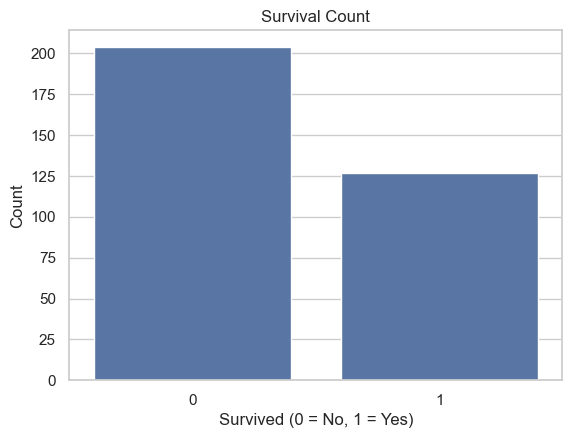

In [293]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")

plt.subplot(2, 2, 1)
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

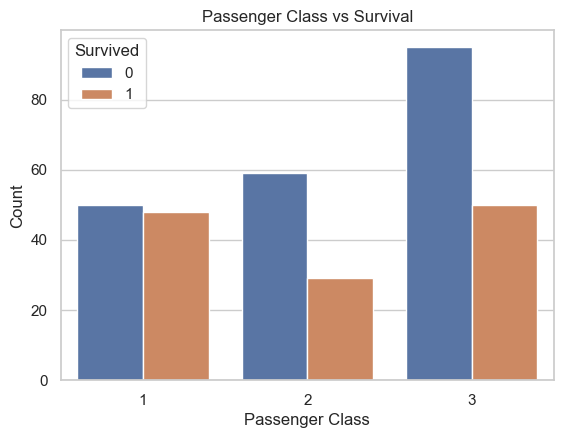

In [295]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")

plt.subplot(2, 2, 2)
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Passenger Class vs Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.show()

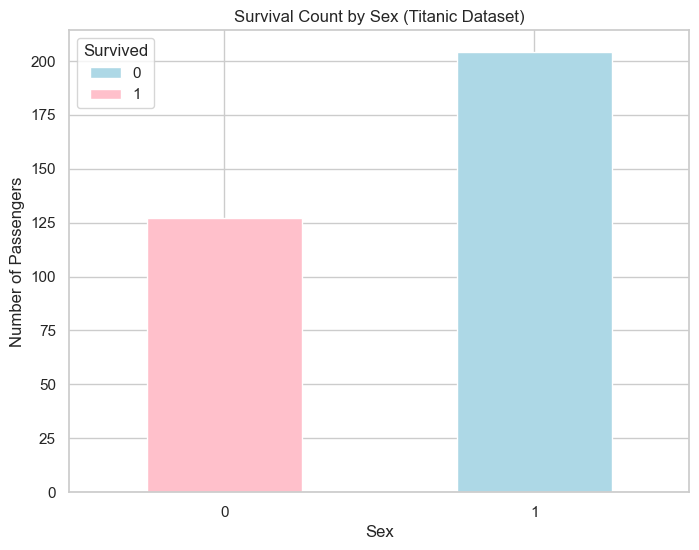

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

survival_count = pd.crosstab(df['Sex'], df['Survived'], rownames=['Sex'], colnames=['Survived'])

survival_count.plot(kind='bar', stacked=True, color=['lightblue', 'pink'], figsize=(8,6))

plt.title('Survival Count by Sex (Titanic Dataset)')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)

plt.show()

In [299]:
predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
predictions_df["Actual Status"] = predictions_df["Actual"].map({1: "Survived", 0: "Not Survived"})
predictions_df["Predicted Status"] = predictions_df["Predicted"].map({1: "Survived", 0: "Not Survived"})

predictions_df.head(10)

,Actual,Predicted,Actual Status,Predicted Status
0,0,0,Not Survived,Not Survived
1,0,0,Not Survived,Not Survived
2,0,0,Not Survived,Not Survived
3,1,1,Survived,Survived
4,0,0,Not Survived,Not Survived
5,0,0,Not Survived,Not Survived
6,1,1,Survived,Survived
7,0,0,Not Survived,Not Survived
8,0,0,Not Survived,Not Survived
9,0,0,Not Survived,Not Survived


In [305]:
sample = np.array([[3, 1, 22.0, 1, 0, 7.25, 2]])  # Third-class male, age 22, embarked from S
prediction = model.predict(sample)
print("Predicted Survival (1=Survived, 0=Not Survived):", prediction[0])

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.